# Dataset SOYBEAN

## Imports

In [1]:
#!pip install scipy
import os
import sys
from scipy.io import arff
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectFromModel, SelectKBest, chi2
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone
from sklearn.metrics import classification_report, confusion_matrix

# Add the parent directory to sys.path to be able to import own packages from outside the notebooks directory
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# some helper functions (see src directory for details)
from src.utils import *
from src.evaluation import *

## Data Inspection

In [2]:
# Load the data and catch a quick glimpse.
curr_dir = os.getcwd()
data_path = os.path.join(curr_dir, '..', 'data', 'soybean/dataset_soybean.arff')

with open(data_path, 'r') as f:
    arff_data, meta = arff.loadarff(f)
cols = meta.names()
df_soybean = pd.DataFrame(arff_data, columns=cols)
df_soybean = df_soybean.select_dtypes([object])
df_soybean = df_soybean.stack().str.decode('utf-8').unstack()

df_soybean.describe()

,date,plant-stand,precip,temp,hail,crop-hist,area-damaged,severity,seed-tmt,germination,...,sclerotia,fruit-pods,fruit-spots,seed,mold-growth,seed-discolor,seed-size,shriveling,roots,class
count,683,683,683,683,683,683,683,683,683,683,...,683,683,683,683,683,683,683,683,683,683
unique,8,3,4,4,3,5,5,4,4,4,...,3,5,5,3,3,3,3,3,4,19
top,september,normal,gt-norm,norm,yes,same-lst-two-yrs,low-areas,pot-severe,none,80-89,...,absent,norm,absent,norm,absent,absent,norm,absent,norm,brown-spot
freq,149,354,459,374,435,219,227,322,305,213,...,625,407,345,476,524,513,532,539,551,92


C:\Users\PC\AppData\Local\Temp\ipykernel_12016\3293990450.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df_soybean['class'], order=df_soybean['class'].value_counts().index, palette='viridis')


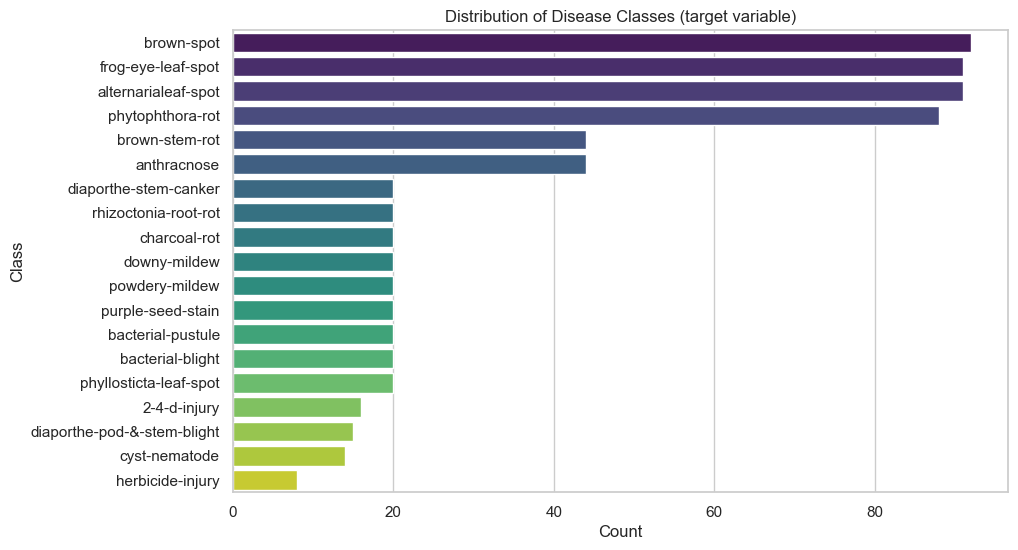

In [3]:
sns.set_theme(style='whitegrid')
plt.figure(figsize=(10,6))
sns.countplot(y=df_soybean['class'], order=df_soybean['class'].value_counts().index, palette='viridis')
plt.title('Distribution of Disease Classes (target variable)')
plt.xlabel('Count')
plt.ylabel('Class')
plt.show()

Because of the lack of samples for the last 4 classes (less than 20), we will remove them from the dataset as was done in previous works. We remove these because it is hard to predict and capture the characteristics of these classes, with such a small sample.

In [4]:

df_soybean_reduced = df_soybean[~df_soybean['class'].isin(['herbicide-injury', 'cyst-nematode', 'diaporthe-pod-&-stem-blight', '2-4-d-injury'])].reset_index(drop=True)

In [5]:
X = df_soybean_reduced.drop(columns=['class'])
y = df_soybean_reduced['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=123)

categorical_features = X.columns

### Missing Value Inspection

In [6]:
sum(df_soybean_reduced.isnull().sum())

0

At first seems like there are no missing values, however when we look at the dataset description, we see that missing values are denoted as "?" so we cant check for them like this

In [7]:
def missing_values_table(df):
    results = []

    for column in df.columns:
        count = (df[column] == '?').sum()
        percent = (count / len(df)) * 100
        results.append({
            'Column': column,
            'Missing_Count': count,
            'Missing_Percent': percent
        })

    results_df = pd.DataFrame(results)
    results_df = results_df[results_df['Missing_Count'] > 0].sort_values('Missing_Percent', ascending=False)

    print("Missing Values Analysis (sorted by %):")
    print("=" * 40)

    if len(results_df) > 0:
        for _, row in results_df.iterrows():
            print(f"{row['Column']}: {row['Missing_Count']} missing ({row['Missing_Percent']:.1f}%)")
    else:
        print("No '?' values found in any column!")
missing_values_table(df_soybean_reduced)

Missing Values Analysis (sorted by %):
hail: 68 missing (10.8%)
severity: 68 missing (10.8%)
seed-tmt: 68 missing (10.8%)
germination: 68 missing (10.8%)
lodging: 68 missing (10.8%)
seed-discolor: 68 missing (10.8%)
mold-growth: 68 missing (10.8%)
seed: 68 missing (10.8%)
fruit-spots: 68 missing (10.8%)
fruit-pods: 68 missing (10.8%)
fruiting-bodies: 68 missing (10.8%)
seed-size: 68 missing (10.8%)
shriveling: 68 missing (10.8%)
leaf-mild: 55 missing (8.7%)
leaf-malf: 55 missing (8.7%)
leafspots-halo: 55 missing (8.7%)
leafspots-marg: 55 missing (8.7%)
leaf-shread: 55 missing (8.7%)
leafspot-size: 55 missing (8.7%)


A lot of the columns have missing values (32 / 36), but its not that bad since they dont even exceed 25% for any of the columns (~12% overall)
We will try the following methods t handle missing values:
- mode imputation (repalcing with most frequent) - (using `SimpleImputer` with indicator)
- passthrough - keep "?" as a missing category (maybe missing contains information)

### Encoding

When it comes to converting the categorical variables into numerical ones, we will try the following encoding methods:
- One Hot encoding-creates binary columns for each unique value -> good for numeric methods such as KNN and SVM
- Ordinal encoding-converts nominal to integer codes -> good for tree-based methods


### Class Imbalance

When we inspected the class distributions before, we noticed that it is imbalanced. This means to get the best results we need to:
- stratify our test and train split
- use `StratifedKFold` for CV
- for `DecisionTree` and `SVM` try balanced weights
- use performance metrics that are not snesitive to class imbalance -> balanced accuracy; f1 score

In [8]:
#this shows the class distribution -> imbalanced!
y.value_counts(normalize=True)

class
brown-spot                0.146032
frog-eye-leaf-spot        0.144444
alternarialeaf-spot       0.144444
phytophthora-rot          0.139683
anthracnose               0.069841
brown-stem-rot            0.069841
diaporthe-stem-canker     0.031746
downy-mildew              0.031746
powdery-mildew            0.031746
charcoal-rot              0.031746
rhizoctonia-root-rot      0.031746
purple-seed-stain         0.031746
bacterial-pustule         0.031746
bacterial-blight          0.031746
phyllosticta-leaf-spot    0.031746
Name: proportion, dtype: float64

## Model training

We we define all of our preprocessing steps and models with sample hyperparameters. Afterwards we try out and evaluate all the different combinations using `StratifedKFold`, as well as using `GridSearchCV` to find the optimal hyperparameters for all the models.

In [9]:
# --- Imputers ---
imputers = {
    'modeIndicator': SimpleImputer(strategy='most_frequent', add_indicator=True, missing_values='?'),
    'none': 'passthrough',
}

# --- Encoders ---
encoders = {
    'onehot': OneHotEncoder(handle_unknown='ignore', sparse_output=False),
    'ordinal': OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
}

# --- Scalers ---
scalers = {
    'none': 'passthrough',
    'standard': StandardScaler(with_mean=False)
}


In [10]:
models = {
    'DecisionTree': (
        DecisionTreeClassifier(random_state=42),
        {'clf__max_depth': [None, 5, 10], 'clf__criterion': ['gini', 'entropy'], 'clf__class_weight': [None, 'balanced']}
    ),
    'KNN': (
        KNeighborsClassifier(),
        {'clf__n_neighbors': [3, 5, 7], 'clf__weights': ['uniform', 'distance']}
    ),
    'SVM': (
        SVC(random_state=42),
        {'clf__C': [0.1, 1, 10], 'clf__kernel': ['linear', 'rbf'], 'clf__class_weight': [None, 'balanced']}
    )
}


In [11]:
#helper function to extract parameters from an estimator
def get_estimator_params(estimator):
    """Extract parameters from a scikit-learn estimator"""
    params = {}
    for name in estimator.get_params():
        if not name.startswith('_'):
            try:
                value = getattr(estimator, name)
                params[name] = str(value)
            except AttributeError:
                continue
    return params

In [12]:
results = []

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
for imp_name, imputer in imputers.items():
    for enc_name, encoder in encoders.items():
        for sc_name, scaler in scalers.items():
            for model_name, (clf, param_grid) in models.items():
                
                #preprocessing pipeline
                preprocessor = ColumnTransformer([
                    ('cat', Pipeline([
                        ('imputer', imputer),
                        ('encoder', encoder),
                        ('scaler', scaler)
                    ]), categorical_features)
                ])

                pipe = Pipeline([
                    ('preprocess', preprocessor),
                    ('clf', clf)
                ])

                # === GRID SEARCH ===
                grid = GridSearchCV(
                    estimator=pipe,
                    param_grid=param_grid,
                    scoring='f1_macro',
                    cv=cv,
                    n_jobs=-1
                )

                grid.fit(X_train, y_train)
                best_model = grid.best_estimator_
                y_pred_best = best_model.predict(X_test)

                preprocessing_params = {
                    'imputer': imp_name,
                    'encoder': enc_name,
                    'scaler': sc_name
                }

                eval_dict_grid = evaluate_run(
                    name=f"Grid {imp_name}_{enc_name}_{sc_name}_{model_name}",
                    y_true=y_test,
                    y_pred=y_pred_best,
                    task_type="classification"
                )
                metrics_grid = [eval_dict_grid]
                df_metrics_grid = pd.DataFrame(metrics_grid)
                agg_grid = df_metrics_grid[['accuracy', 'balanced_accuracy', 'f1', 'precision', 'recall']].agg(['mean', 'std'])
                
                results.append({
                    "Preprocessing": imp_name + "_" + enc_name + "_" + sc_name,
                    "Classifier": model_name,
                    "accuracy_mean": agg_grid.loc['mean', 'accuracy'],
                    "accuracy_std": agg_grid.loc['std', 'accuracy'],
                    "b_accuracy_mean": agg_grid.loc['mean', 'balanced_accuracy'],
                    "b_accuracy_std": agg_grid.loc['std', 'balanced_accuracy'],
                    "f1_mean": agg_grid.loc['mean', 'f1'],
                    "f1_std": agg_grid.loc['std', 'f1'],
                    "precision_mean": agg_grid.loc['mean', 'precision'],
                    "recall_mean": agg_grid.loc['mean', 'recall'],
                    "preprocessing": preprocessing_params,
                    "model_params": grid.best_params_,
                    "cv_score": grid.best_score_,
                    "search_type": "grid"
                })


                # === DEFAULT PARAMETERS ===

                fold_metrics = []
                for fold, (train_idx, test_idx) in enumerate(cv.split(X_train, y_train)):
                    X_train_fold, X_test_fold = X_train.iloc[train_idx], X_train.iloc[test_idx]
                    y_train_fold, y_test_fold = y_train.iloc[train_idx], y_train.iloc[test_idx]

                    pipe.fit(X_train_fold, y_train_fold)
                    y_pred = pipe.predict(X_test_fold)

                    eval_dict = evaluate_run(
                        name=f"Default {imp_name}_{enc_name}_{sc_name}_{model_name}",
                        y_true=y_test_fold,
                        y_pred=y_pred,
                        task_type="classification"
                    )
                    fold_metrics.append(eval_dict)
                
                df_metrics = pd.DataFrame(fold_metrics)
                agg = df_metrics[['accuracy', 'balanced_accuracy', 'f1', 'precision', 'recall']].agg(['mean', 'std'])
                
                default_params = {
                    name.replace('clf__', ''): value 
                    for name, value in clf.get_params().items() 
                    if not name.startswith('_') and not isinstance(value, (list, dict))
                }
                
                results.append({
                    "Preprocessing": imp_name + "_" + enc_name + "_" + sc_name,
                    "Classifier": model_name,
                    "accuracy_mean": agg.loc['mean', 'accuracy'],
                    "accuracy_std": agg.loc['std', 'accuracy'],
                    "b_accuracy_mean": agg.loc['mean', 'balanced_accuracy'],
                    "b_accuracy_std": agg.loc['std', 'balanced_accuracy'],
                    "f1_mean": agg.loc['mean', 'f1'],
                    "f1_std": agg.loc['std', 'f1'],
                    "precision_mean": agg.loc['mean', 'precision'],
                    "recall_mean": agg.loc['mean', 'recall'],
                    "preprocessing": preprocessing_params,
                    "model_params": default_params,
                    "cv_score": df_metrics['f1'].mean(),
                    "search_type": "default"
                })

results_df = pd.DataFrame(results).sort_values(by='f1_mean', ascending=False)

c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

## Model Evaluation
Since we created all of the combinations, it would be too much to plot at once, so we only plot the 10 best performing preprocessing combinations.

From the model evaluations, we can see that SVM seems to be performing the best, as well as onehot encoding being the better of the two, since ordinal encoding is benefiecial only for DecisionTree. Scaling also helps the numerical methods, but surprisingly, KNN performs worse with scaled data than without.

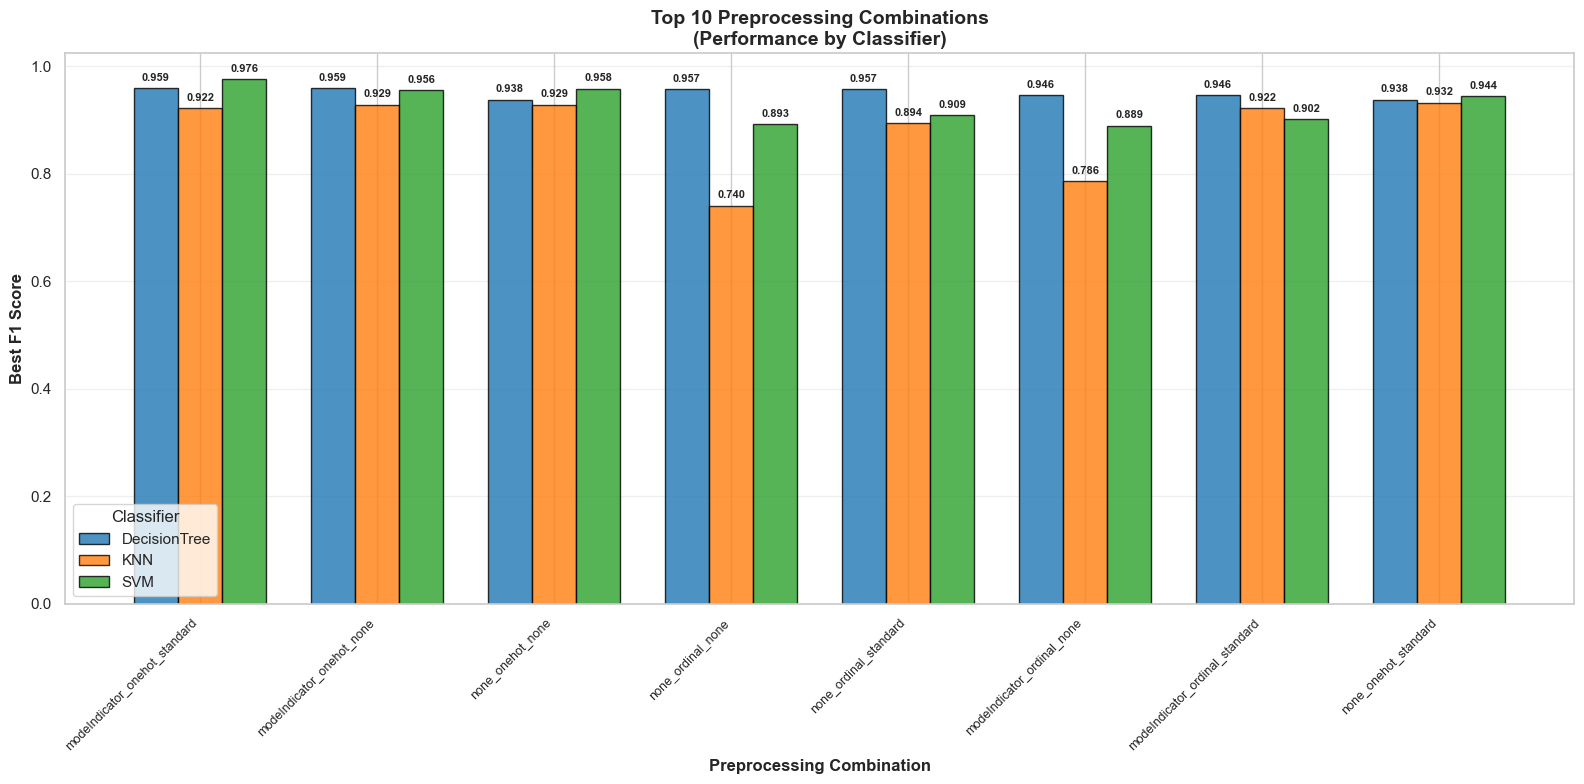

In [13]:
fig, ax = plt.subplots(figsize=(16, 8))

top_10_preprocessing = results_df.groupby('Preprocessing')['f1_mean'].max().nlargest(10).index

model_colors = {
    'DecisionTree': '#1f77b4',  
    'KNN': '#ff7f0e',           
    'SVM': '#2ca02c'            
}

models_list = ['DecisionTree', 'KNN', 'SVM']
bar_width = 0.25
x_pos = np.arange(len(top_10_preprocessing))

for i, model in enumerate(models_list):
    model_scores = []
    for preproc in top_10_preprocessing:
        combo_data = results_df[
            (results_df['Preprocessing'] == preproc) & 
            (results_df['Classifier'] == model)
        ]
        if len(combo_data) > 0:
            model_scores.append(combo_data['f1_mean'].max())
        else:
            model_scores.append(0)
    
    ax.bar(x_pos + i * bar_width, model_scores, bar_width, 
            label=model, color=model_colors[model], alpha=0.8, edgecolor='black')

ax.set_xlabel('Preprocessing Combination', fontsize=12, fontweight='bold')
ax.set_ylabel('Best F1 Score', fontsize=12, fontweight='bold')
ax.set_title('Top 10 Preprocessing Combinations\n(Performance by Classifier)', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos + bar_width)
ax.set_xticklabels([label for label in top_10_preprocessing], rotation=45, ha='right', fontsize=9)
ax.legend(title='Classifier')
ax.grid(True, alpha=0.3, axis='y')

for i, preproc in enumerate(top_10_preprocessing):
    for j, model in enumerate(models_list):
        combo_data = results_df[
            (results_df['Preprocessing'] == preproc) & 
            (results_df['Classifier'] == model)
        ]
        if len(combo_data) > 0:
            score = combo_data['f1_mean'].max()
            if score > 0:
                ax.text(i + j * bar_width, score + 0.01, f'{score:.3f}', 
                       ha='center', va='bottom', fontweight='bold', fontsize=8)

plt.tight_layout()
plt.show()

In [14]:
#Get the best performing version of each classifier type
best_per_classifier = results_df.loc[results_df.groupby('Classifier')['f1_mean'].idxmax()]

print("Single best version of each classifier:")
best_per_classifier

Single best version of each classifier:


,Preprocessing,Classifier,accuracy_mean,accuracy_std,b_accuracy_mean,b_accuracy_std,f1_mean,f1_std,precision_mean,recall_mean,preprocessing,model_params,cv_score,search_type
0,modeIndicator_onehot_none,DecisionTree,0.952381,NaN,0.951852,NaN,0.959454,NaN,0.978519,0.951852,"{'imputer': 'modeIndicator', 'encoder': 'oneho...","{'clf__class_weight': None, 'clf__criterion': ...",0.94364,grid
33,none_onehot_standard,KNN,0.910510,0.034667,0.934127,0.034047,0.932140,0.037523,0.946065,0.934127,"{'imputer': 'none', 'encoder': 'onehot', 'scal...","{'algorithm': 'auto', 'leaf_size': 30, 'metric...",0.93214,default
10,modeIndicator_onehot_standard,SVM,0.960317,NaN,0.981481,NaN,0.975688,NaN,0.974545,0.981481,"{'imputer': 'modeIndicator', 'encoder': 'oneho...","{'clf__C': 10, 'clf__class_weight': 'balanced'...",0.95223,grid


We can see that so far, the best performing model in terms of balanced accuracy and F1 score, is SVM with preprocessing of mode imputation with Indicator, onehot encoding and standard scaling. The parameters of the SVM were chosen by grid search and are a C of 10, a balanced class_weight and rbf kernel. This shows the importance of using balanced weight for our class imbalance.

## Feature Selection

We also experiment with feature selection, although with 35 features, we do not need much reduction. We will try:
- passthrough -> no reduction
- chi_k20 -> univariate selection
- rf_importance -> based on feature importance

Both of the selection techniques will be limited to 20 features max so the comparison is fair.

In [15]:
#preprocessing pipeline for feature selection
def preprocess_for_selection(X):
    """Preprocess data to prepare for feature selection"""
    imp = SimpleImputer(strategy='most_frequent', missing_values='?')
    X_imp = pd.DataFrame(imp.fit_transform(X), columns=X.columns)
    
    enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_encoded = pd.DataFrame(enc.fit_transform(X_imp), columns=X_imp.columns)
    
    scaler = StandardScaler(with_mean=False)
    X_scaled = pd.DataFrame(scaler.fit_transform(X_encoded), columns=X_encoded.columns)
    
    return X_scaled, X_encoded

X_scaled, X_encoded = preprocess_for_selection(X)

In [16]:
feature_selectors = {
    'passthrough': 'passthrough',
    'chi2_k20': SelectKBest(chi2, k=20),
    'rf_importance': SelectFromModel(
        estimator=RandomForestClassifier(n_estimators=100, random_state=42),
        max_features=20
    )
}

feature_selection_results = []
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

X_processed = X_scaled 
y_target = y

for selector_name, selector in feature_selectors.items():
    print(f"Processing feature selector: {selector_name}")
    
    for model_name, (clf, param_grid) in models.items():
        print(f"  With classifier: {model_name}")
        
        fold_metrics = []
        fold_features = []
        
        for fold, (train_idx, test_idx) in enumerate(cv.split(X_processed, y_target)):
            X_train_fold, X_test_fold = X_processed.iloc[train_idx], X_processed.iloc[test_idx]
            y_train_fold, y_test_fold = y_target.iloc[train_idx], y_target.iloc[test_idx]
            
            if selector_name == 'passthrough':
                X_train_selected = X_train_fold
                X_test_selected = X_test_fold
                selected_features = X_train_fold.columns.tolist()
                n_features = len(selected_features)
            else:
                fold_selector = clone(selector)
                
                fold_selector.fit(X_train_fold, y_train_fold)
                
                X_train_selected = fold_selector.transform(X_train_fold)
                X_test_selected = fold_selector.transform(X_test_fold)
                
                if hasattr(fold_selector, 'get_support'):
                    selected_mask = fold_selector.get_support()
                    selected_features = X_train_fold.columns[selected_mask].tolist()
                    n_features = len(selected_features)
                else:
                    selected_features = [f'Feature_{i}' for i in range(X_train_selected.shape[1])]
                    n_features = X_train_selected.shape[1]
            
            if not isinstance(X_train_selected, pd.DataFrame):
                X_train_selected = pd.DataFrame(X_train_selected, columns=selected_features)
                X_test_selected = pd.DataFrame(X_test_selected, columns=selected_features)
            
            fold_features.append({
                'fold': fold,
                'n_features': n_features,
                'features': selected_features
            })
            
            fold_clf = clone(clf)
            fold_clf.fit(X_train_selected, y_train_fold)
            y_pred = fold_clf.predict(X_test_selected)
            
            eval_dict = evaluate_run(
                name=f"{selector_name}_{model_name}_fold{fold}",
                y_true=y_test_fold,
                y_pred=y_pred,
                task_type="classification"
            )
            fold_metrics.append(eval_dict)
        
        df_metrics = pd.DataFrame(fold_metrics)
        agg = df_metrics[['accuracy', 'balanced_accuracy', 'f1', 'precision', 'recall']].agg(['mean', 'std'])
        
        feature_consistency = {}
        for feature_set in fold_features:
            for feature in feature_set['features']:
                feature_consistency[feature] = feature_consistency.get(feature, 0) + 1
        
        total_folds = len(fold_features)
        consistent_features = {feat: count for feat, count in feature_consistency.items() if count == total_folds}
        consistency_ratio = len(consistent_features) / len(feature_consistency) if feature_consistency else 0
        
        feature_selection_results.append({
            'feature_selector': selector_name,
            'classifier': model_name,
            'n_features_mean': round(np.mean([f['n_features'] for f in fold_features]), 0),
            'n_features_std': np.std([f['n_features'] for f in fold_features]),
            'feature_consistency_ratio': consistency_ratio,
            'total_features_considered': len(feature_consistency),
            'consistent_features_count': len(consistent_features),
            "accuracy_mean": agg.loc['mean', 'accuracy'],
            "accuracy_std": agg.loc['std', 'accuracy'],
            "f1_mean": agg.loc['mean', 'f1'],
            "f1_std": agg.loc['std', 'f1'],
            "precision_mean": agg.loc['mean', 'precision'],
            "precision_std": agg.loc['std', 'precision'],
            "recall_mean": agg.loc['mean', 'recall'],
            "recall_std": agg.loc['std', 'recall'],
            "balanced_accuracy_mean": agg.loc['mean', 'balanced_accuracy'],
            "balanced_accuracy_std": agg.loc['std', 'balanced_accuracy'],
            'fold_details': fold_features
        })

fs_results_df = pd.DataFrame(feature_selection_results)
fs_results_df = fs_results_df.sort_values('f1_mean', ascending=False)

print("Feature selection evaluation completed!")
print(f"Total combinations evaluated: {len(fs_results_df)}")
print(f"\nTop 5 performing combinations:")
print(fs_results_df[['feature_selector', 'classifier', 'f1_mean', 'n_features_mean', 'feature_consistency_ratio']].head(5).round(4))

Processing feature selector: passthrough
  With classifier: DecisionTree
  With classifier: KNN


c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


  With classifier: SVM


c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Processing feature selector: chi2_k20
  With classifier: DecisionTree
  With classifier: KNN


...

  With classifier: KNN


c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


  With classifier: SVM


c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

Feature selection evaluation completed!
Total combinations evaluated: 9

Top 5 performing combinations:
  feature_selector    classifier  f1_mean  n_features_mean  \
0      passthrough  DecisionTree   0.9354             35.0   
6    rf_importance  DecisionTree   0.9131             15.0   
2      passthrough           SVM   0.9118             35.0   
3         chi2_k20  DecisionTree   0.9117             20.0   
1      passthrough           KNN   0.8946             35.0   

   feature_consistency_ratio  
0                     1.0000  
6                     0.6667  
2                     1.0000  
3                     1.0000  
1                     1.0000  


In [17]:
fs_results_df

,feature_selector,classifier,n_features_mean,n_features_std,feature_consistency_ratio,total_features_considered,consistent_features_count,accuracy_mean,accuracy_std,f1_mean,f1_std,precision_mean,precision_std,recall_mean,recall_std,balanced_accuracy_mean,balanced_accuracy_std,fold_details
0,passthrough,DecisionTree,35.0,0.000000,1.000000,35,35,0.920635,0.036657,0.935356,0.035302,0.940576,0.034876,0.941519,0.032577,0.941519,0.032577,"[{'fold': 0, 'n_features': 35, 'features': ['d..."
6,rf_importance,DecisionTree,15.0,1.044031,0.666667,18,12,0.909524,0.038191,0.913088,0.044992,0.937777,0.044324,0.911519,0.042830,0.911519,0.042830,"[{'fold': 0, 'n_features': 16, 'features': ['d..."
2,passthrough,SVM,35.0,0.000000,1.000000,35,35,0.895238,0.028197,0.911762,0.043307,0.943241,0.041301,0.904593,0.045176,0.904593,0.045176,"[{'fold': 0, 'n_features': 35, 'features': ['d..."
3,chi2_k20,DecisionTree,20.0,0.000000,1.000000,20,20,0.879365,0.032787,0.911733,0.028240,0.937562,0.025766,0.906370,0.030374,0.906370,0.030374,"[{'fold': 0, 'n_features': 20, 'features': ['p..."
1,passthrough,KNN,35.0,0.000000,1.000000,35,35,0.880952,0.041829,0.894569,0.051506,0.914478,0.054910,0.892333,0.051718,0.892333,0.051718,"[{'fold': 0, 'n_features': 35, 'features': ['d..."
5,chi2_k20,SVM,20.0,0.000000,1.000000,20,20,0.865079,0.036080,0.875925,0.043870,0.898223,0.049439,0.875778,0.037274,0.875778,0.037274,"[{'fold': 0, 'n_features': 20, 'features': ['p..."
7,rf_importance,KNN,15.0,1.044031,0.666667,18,12,0.860317,0.026771,0.854592,0.035759,0.890406,0.038131,0.851593,0.041470,0.851593,0.041470,"[{'fold': 0, 'n_features': 16, 'features': ['d..."
8,rf_importance,SVM,15.0,1.044031,0.666667,18,12,0.833333,0.050334,0.848471,0.041305,0.872405,0.047778,0.861037,0.039316,0.861037,0.039316,"[{'fold': 0, 'n_features': 16, 'features': ['d..."
4,chi2_k20,KNN,20.0,0.000000,1.000000,20,20,0.776190,0.030348,0.826605,0.037991,0.884841,0.056682,0.838593,0.036810,0.838593,0.036810,"[{'fold': 0, 'n_features': 20, 'features': ['p..."


From these results, we can see that feature selection only really has a positive effect in decision trees, and even there passthrough seems to be the best performing option

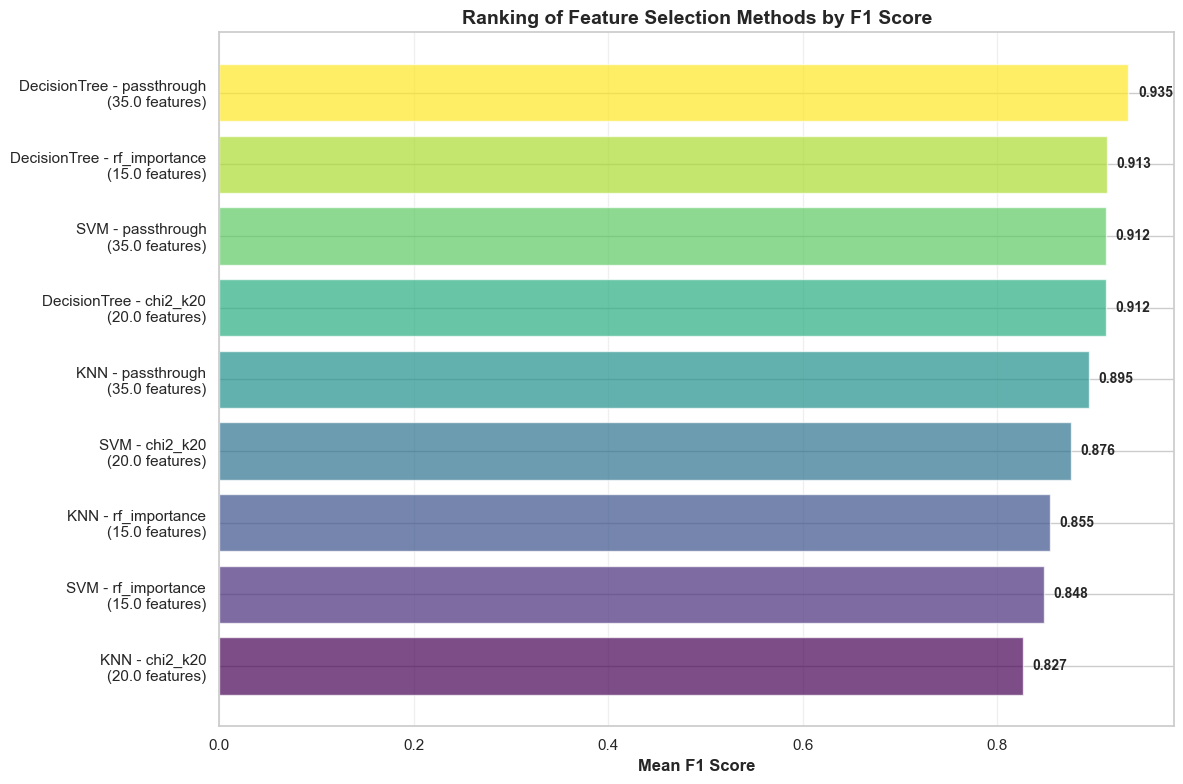

In [18]:
plt.figure(figsize=(12, 8))

ranked_data = fs_results_df.sort_values('f1_mean', ascending=True)

y_pos = np.arange(len(ranked_data))
colors = plt.cm.viridis(np.linspace(0, 1, len(ranked_data)))

bars = plt.barh(y_pos, ranked_data['f1_mean'], color=colors, alpha=0.7, height=0.8)
plt.yticks(y_pos, [f"{row['classifier']} - {row['feature_selector']}\n({row['n_features_mean']} features)" 
                   for _, row in ranked_data.iterrows()], fontsize=11)
plt.xlabel('Mean F1 Score', fontsize=12, fontweight='bold')
plt.title('Ranking of Feature Selection Methods by F1 Score', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')

for bar, value in zip(bars, ranked_data['f1_mean']):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
             f'{value:.3f}', ha='left', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## Combining 

Finally, we combine all these steps into one and try out all of the different model, parameter, preprocessing and feature selection combinations and evaluate their final performance on the test data.

In [19]:
def comprehensive_pipeline_comparison(X_train, X_test, y_train, y_test, categorical_features):
    """
    Comprehensive pipeline comparison including preprocessing, feature selection, and grid search
    """
    results = []
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
    
    feature_selectors = {
        'passthrough': 'passthrough',
        'chi2_k15': SelectKBest(chi2, k=20),
        'rf_importance': SelectFromModel(
            estimator=RandomForestClassifier(n_estimators=100, random_state=42),
            max_features=20
        )
    }
    
    for imp_name, imputer in imputers.items():
        for enc_name, encoder in encoders.items():
            for sc_name, scaler in scalers.items():
                for fs_name, feature_selector in feature_selectors.items():
                    for model_name, (clf, param_grid) in models.items():
                        
                        #preprocessing pipeline
                        preprocessor = ColumnTransformer([
                            ('cat', Pipeline([
                                ('imputer', imputer),
                                ('encoder', encoder),
                                ('scaler', scaler)
                            ]), categorical_features)
                        ])

                        #pipeline with feature selection
                        pipe = Pipeline([
                            ('preprocess', preprocessor),
                            ('feature_selector', feature_selector),
                            ('clf', clf)
                        ])

                        #=== GRID SEARCH ===

                        grid = GridSearchCV(
                            estimator=pipe,
                            param_grid=param_grid,
                            scoring='f1_macro',
                            cv=cv,
                            n_jobs=-1,
                            error_score='raise'
                        )
                        
                        try:
                            grid.fit(X_train, y_train)
                            best_model = grid.best_estimator_
                            y_pred_best = best_model.predict(X_test)

                            if fs_name == 'passthrough':
                                n_features = X_train.shape[1]
                            else:
                                fitted_selector = best_model.named_steps['feature_selector']
                                if hasattr(fitted_selector, 'get_support'):
                                    n_features = sum(fitted_selector.get_support())
                                else:
                                    n_features = X_train.shape[1]

                            eval_dict_grid = evaluate_run(
                                name=f"Grid {imp_name}_{enc_name}_{sc_name}_{fs_name}_{model_name}",
                                y_true=y_test,
                                y_pred=y_pred_best,
                                task_type="classification"
                            )
                            metrics_grid = [eval_dict_grid]
                            df_metrics_grid = pd.DataFrame(metrics_grid)
                            agg_grid = df_metrics_grid[['accuracy', 'balanced_accuracy', 'f1', 'precision', 'recall']].agg(['mean', 'std'])
                            
                            results.append({
                                "Preprocessing": f"{imp_name}_{enc_name}_{sc_name}",
                                "Feature_Selection": fs_name,
                                "Classifier": model_name,
                                "n_features": n_features,
                                "accuracy_mean": agg_grid.loc['mean', 'accuracy'],
                                "accuracy_std": agg_grid.loc['std', 'accuracy'],
                                "b_accuracy_mean": agg_grid.loc['mean', 'balanced_accuracy'],
                                "b_accuracy_std": agg_grid.loc['std', 'balanced_accuracy'],
                                "f1_mean": agg_grid.loc['mean', 'f1'],
                                "f1_std": agg_grid.loc['std', 'f1'],
                                "precision_mean": agg_grid.loc['mean', 'precision'],
                                "recall_mean": agg_grid.loc['mean', 'recall'],
                                "preprocessing_params": {
                                    'imputer': imp_name,
                                    'encoder': enc_name, 
                                    'scaler': sc_name
                                },
                                "feature_selector": fs_name,
                                "model_params": grid.best_params_,
                                "cv_score": grid.best_score_,
                                "search_type": "grid"
                            })

                        except Exception as e:
                            print(f"Error in grid search for {imp_name}_{enc_name}_{sc_name}_{fs_name}_{model_name}: {e}")
                            continue
                            
                        #=== DEFAULT PARAMETERS ===

                        try:
                            fold_metrics = []
                            for fold, (train_idx, test_idx) in enumerate(cv.split(X_train, y_train)):
                                X_train_fold, X_test_fold = X_train.iloc[train_idx], X_train.iloc[test_idx]
                                y_train_fold, y_test_fold = y_train.iloc[train_idx], y_train.iloc[test_idx]

                                pipe.fit(X_train_fold, y_train_fold)
                                y_pred = pipe.predict(X_test_fold)

                                eval_dict = evaluate_run(
                                    name=f"Default {imp_name}_{enc_name}_{sc_name}_{fs_name}_{model_name}",
                                    y_true=y_test_fold,
                                    y_pred=y_pred,
                                    task_type="classification"
                                )
                                fold_metrics.append(eval_dict)
                            
                            df_metrics = pd.DataFrame(fold_metrics)
                            agg = df_metrics[['accuracy', 'balanced_accuracy', 'f1', 'precision', 'recall']].agg(['mean', 'std'])
                            
                            if fs_name == 'passthrough':
                                n_features_default = X_train.shape[1]
                            else:
                                temp_selector = feature_selector
                                if temp_selector != 'passthrough':
                                    X_train_processed = preprocessor.fit_transform(X_train_fold)
                                    temp_selector.fit(X_train_processed, y_train_fold)
                                    if hasattr(temp_selector, 'get_support'):
                                        n_features_default = sum(temp_selector.get_support())
                                    else:
                                        n_features_default = X_train.shape[1]
                                else:
                                    n_features_default = X_train.shape[1]
                            
                            default_params = {
                                name.replace('clf__', ''): value 
                                for name, value in clf.get_params().items() 
                                if not name.startswith('_') and not isinstance(value, (list, dict))
                            }
                            
                            results.append({
                                "Preprocessing": f"{imp_name}_{enc_name}_{sc_name}",
                                "Feature_Selection": fs_name,
                                "Classifier": model_name,
                                "n_features": n_features_default,
                                "accuracy_mean": agg.loc['mean', 'accuracy'],
                                "accuracy_std": agg.loc['std', 'accuracy'],
                                "b_accuracy_mean": agg.loc['mean', 'balanced_accuracy'],
                                "b_accuracy_std": agg.loc['std', 'balanced_accuracy'],
                                "f1_mean": agg.loc['mean', 'f1'],
                                "f1_std": agg.loc['std', 'f1'],
                                "precision_mean": agg.loc['mean', 'precision'],
                                "recall_mean": agg.loc['mean', 'recall'],
                                "preprocessing_params": {
                                    'imputer': imp_name,
                                    'encoder': enc_name,
                                    'scaler': sc_name
                                },
                                "feature_selector": fs_name,
                                "model_params": default_params,
                                "cv_score": df_metrics['f1'].mean(),
                                "search_type": "default"
                            })
                            
                        except Exception as e:
                            print(f"Error in default evaluation for {imp_name}_{enc_name}_{sc_name}_{fs_name}_{model_name}: {e}")
                            continue

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(by='f1_mean', ascending=False).reset_index(drop=True)
    
    return results_df

#the runtime is quite long at ~7 minutes, but this makes sense since in total 144 models are trained and evaluated
comprehensive_results_df = comprehensive_pipeline_comparison(X_train, X_test, y_train, y_test, categorical_features)


c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

In [20]:
print(f"Total combinations evaluated: {len(comprehensive_results_df)}")

comprehensive_results_df[['Preprocessing', 'Feature_Selection', 'Classifier', 'n_features', 'f1_mean', 'search_type']].head(15)

Total combinations evaluated: 144


,Preprocessing,Feature_Selection,Classifier,n_features,f1_mean,search_type
0,modeIndicator_onehot_standard,passthrough,SVM,35,0.975688,grid
1,modeIndicator_onehot_none,passthrough,DecisionTree,35,0.959454,grid
2,modeIndicator_onehot_standard,passthrough,DecisionTree,35,0.959454,grid
3,none_onehot_none,passthrough,SVM,35,0.958438,default
4,none_ordinal_none,passthrough,DecisionTree,35,0.956975,grid
5,none_ordinal_standard,passthrough,DecisionTree,35,0.956975,grid
6,modeIndicator_onehot_none,passthrough,SVM,35,0.955781,default
7,none_ordinal_none,rf_importance,SVM,16,0.954582,grid
8,modeIndicator_ordinal_none,passthrough,DecisionTree,35,0.946484,grid
9,modeIndicator_ordinal_standard,passthrough,DecisionTree,35,0.946484,grid


## Final Evaluation

We decided to focus on the best and worst performing models of each classsifier

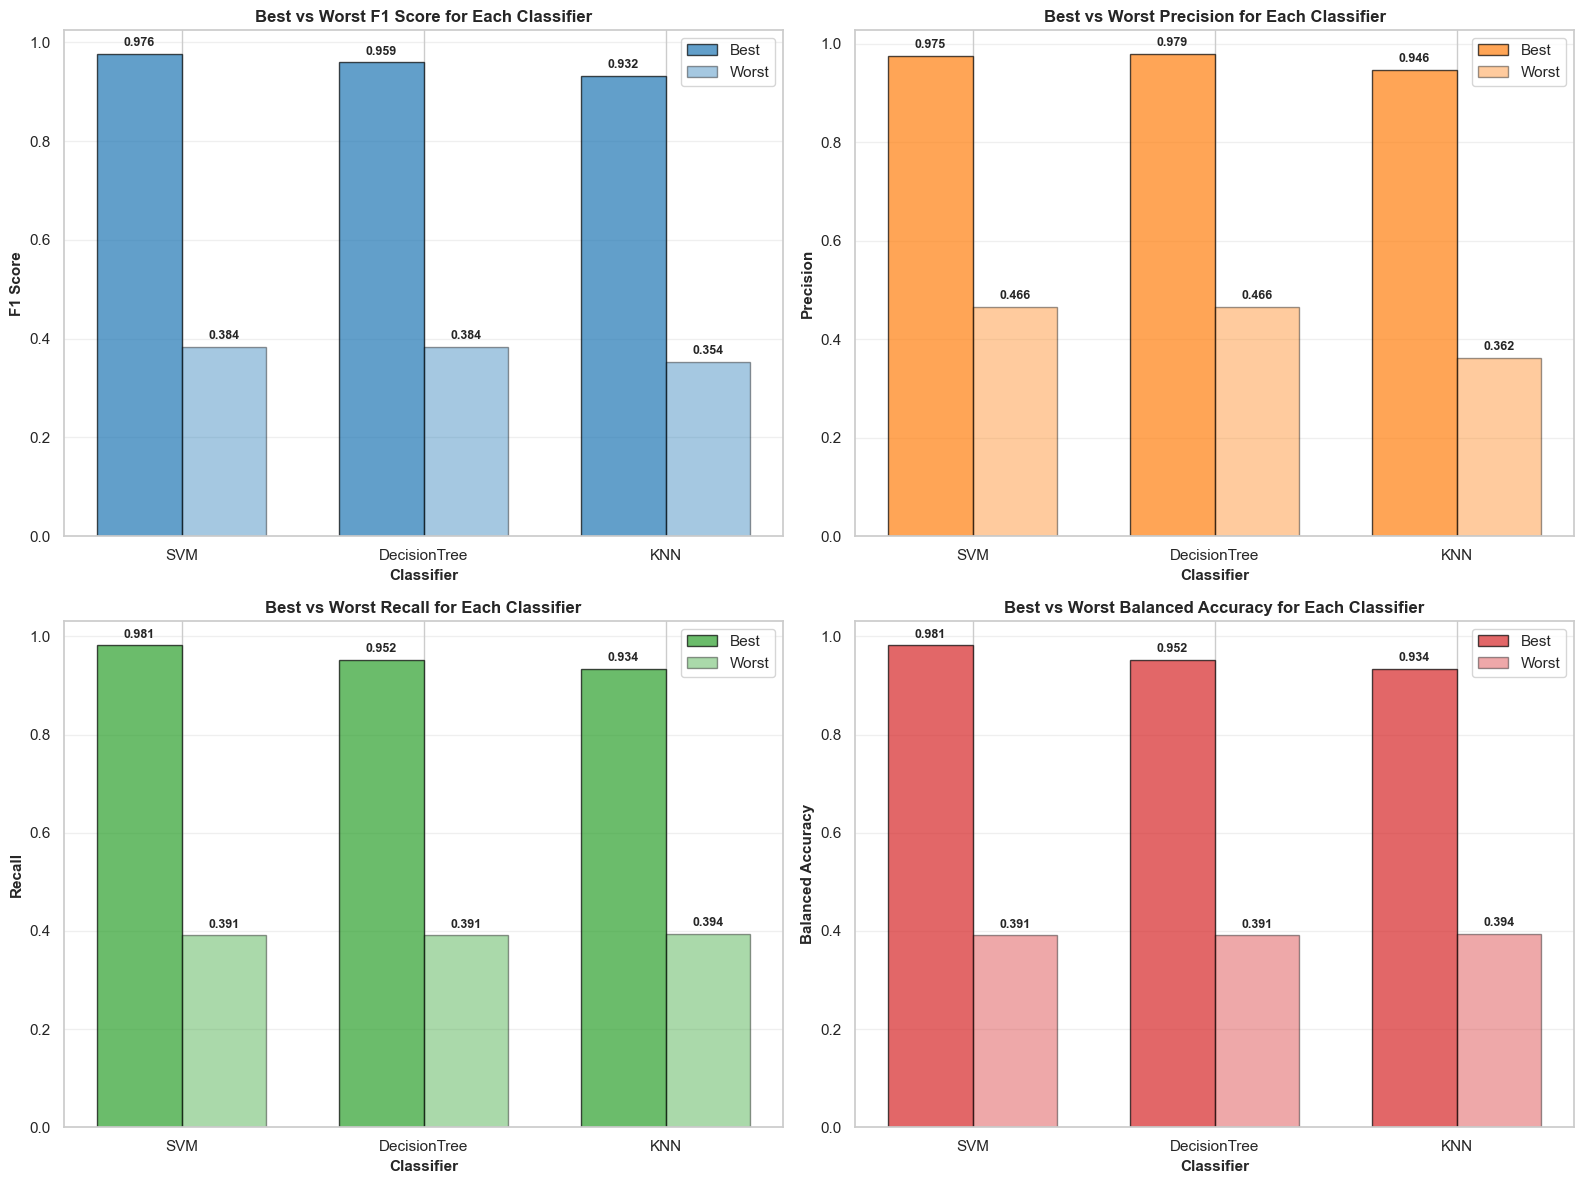

DETAILED CONFIGURATION ANALYSIS:

 SVM:
    BEST PERFORMING:
      F1: 0.976 | Precision: 0.975 | Recall: 0.981 | Bal Acc: 0.981
      Config: modeIndicator_onehot_standard + passthrough
      Features: 35 | Search: grid
    WORST PERFORMING:
      F1: 0.384 | Precision: 0.466 | Recall: 0.391 | Bal Acc: 0.391
      Config: modeIndicator_ordinal_standard + chi2_k15
      Features: 20 | Search: grid
    Performance Gaps: F1: 0.592 | Precision: 0.508 | Recall: 0.591 | Bal Acc: 0.591

 DECISIONTREE:
    BEST PERFORMING:
      F1: 0.959 | Precision: 0.979 | Recall: 0.952 | Bal Acc: 0.952
      Config: modeIndicator_onehot_none + passthrough
      Features: 35 | Search: grid
    WORST PERFORMING:
      F1: 0.384 | Precision: 0.466 | Recall: 0.391 | Bal Acc: 0.391
      Config: modeIndicator_ordinal_standard + chi2_k15
      Features: 20 | Search: grid
    Performance Gaps: F1: 0.575 | Precision: 0.512 | Recall: 0.561 | Bal Acc: 0.561

 KNN:
    BEST PERFORMING:
      F1: 0.932 | Precision: 0

In [21]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

models_list = comprehensive_results_df['Classifier'].unique()
best_worst_data = []

for model in models_list:
    model_data = comprehensive_results_df[comprehensive_results_df['Classifier'] == model]
    
    best_idx = model_data['f1_mean'].idxmax()
    best_row = model_data.loc[best_idx]
    best_worst_data.append({
        'Model': model,
        'Type': 'Best',
        'F1_Score': best_row['f1_mean'],
        'Precision_Score': best_row['precision_mean'],
        'Recall_Score': best_row['recall_mean'],
        'Balanced_Accuracy': best_row['b_accuracy_mean'],
        'Preprocessing': best_row['Preprocessing'],
        'Feature_Selection': best_row['Feature_Selection'],
        'n_features': best_row['n_features'],
        'Search_Type': best_row['search_type']
    })
    
    valid_data = model_data[model_data['f1_mean'] > 0] 
    if len(valid_data) > 0:
        worst_idx = valid_data['f1_mean'].idxmin()
        worst_row = valid_data.loc[worst_idx]
        best_worst_data.append({
            'Model': model,
            'Type': 'Worst',
            'F1_Score': worst_row['f1_mean'],
            'Precision_Score': worst_row['precision_mean'],
            'Recall_Score': worst_row['recall_mean'],
            'Balanced_Accuracy': worst_row['b_accuracy_mean'],
            'Preprocessing': worst_row['Preprocessing'],
            'Feature_Selection': worst_row['Feature_Selection'],
            'n_features': worst_row['n_features'],
            'Search_Type': worst_row['search_type']
        })

best_worst_df = pd.DataFrame(best_worst_data)

x_pos = np.arange(len(models_list))
bar_width = 0.35
metrics = [
    ('F1_Score', 'F1 Score', ax1, '#1f77b4'),
    ('Precision_Score', 'Precision', ax2, '#ff7f0e'),
    ('Recall_Score', 'Recall', ax3, '#2ca02c'),
    ('Balanced_Accuracy', 'Balanced Accuracy', ax4, '#d62728')
]

for metric, metric_name, ax, color in metrics:
    for i, model in enumerate(models_list):
        model_data = best_worst_df[best_worst_df['Model'] == model]
        best_score = model_data[model_data['Type'] == 'Best'][metric].values[0]
        worst_score = model_data[model_data['Type'] == 'Worst'][metric].values[0]
        
        ax.bar(i - bar_width/2, best_score, bar_width, label='Best' if i == 0 else "", 
                color=color, alpha=0.7, edgecolor='black')
        ax.bar(i + bar_width/2, worst_score, bar_width, label='Worst' if i == 0 else "", 
                color=color, alpha=0.4, edgecolor='black')
        
        ax.text(i - bar_width/2, best_score + 0.01, f'{best_score:.3f}', 
                 ha='center', va='bottom', fontweight='bold', fontsize=9)
        ax.text(i + bar_width/2, worst_score + 0.01, f'{worst_score:.3f}', 
                 ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    ax.set_xlabel('Classifier', fontsize=11, fontweight='bold')
    ax.set_ylabel(metric_name, fontsize=11, fontweight='bold')
    ax.set_title(f'Best vs Worst {metric_name} for Each Classifier', fontsize=12, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(models_list)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(bottom=0)

plt.tight_layout()
plt.show()


print("DETAILED CONFIGURATION ANALYSIS:")
print("=" * 100)

for model in models_list:
    model_data = best_worst_df[best_worst_df['Model'] == model]
    best_row = model_data[model_data['Type'] == 'Best'].iloc[0]
    worst_row = model_data[model_data['Type'] == 'Worst'].iloc[0]
    
    print(f"\n {model.upper()}:")
    print(f"    BEST PERFORMING:")
    print(f"      F1: {best_row['F1_Score']:.3f} | Precision: {best_row['Precision_Score']:.3f} | Recall: {best_row['Recall_Score']:.3f} | Bal Acc: {best_row['Balanced_Accuracy']:.3f}")
    print(f"      Config: {best_row['Preprocessing']} + {best_row['Feature_Selection']}")
    print(f"      Features: {best_row['n_features']} | Search: {best_row['Search_Type']}")
    
    print(f"    WORST PERFORMING:")
    print(f"      F1: {worst_row['F1_Score']:.3f} | Precision: {worst_row['Precision_Score']:.3f} | Recall: {worst_row['Recall_Score']:.3f} | Bal Acc: {worst_row['Balanced_Accuracy']:.3f}")
    print(f"      Config: {worst_row['Preprocessing']} + {worst_row['Feature_Selection']}")
    print(f"      Features: {worst_row['n_features']} | Search: {worst_row['Search_Type']}")
    
    f1_gap = best_row['F1_Score'] - worst_row['F1_Score']
    precision_gap = best_row['Precision_Score'] - worst_row['Precision_Score']
    recall_gap = best_row['Recall_Score'] - worst_row['Recall_Score']
    bal_acc_gap = best_row['Balanced_Accuracy'] - worst_row['Balanced_Accuracy']
    
    print(f"    Performance Gaps: F1: {f1_gap:.3f} | Precision: {precision_gap:.3f} | Recall: {recall_gap:.3f} | Bal Acc: {bal_acc_gap:.3f}")

From the results we can see that feature selection overall has a bad effect on the models performance. Interestingly, the best performing decision tree uses onehot encoding instead of ordinal. Looking into it in more detail, we can see that the ordinal encoded performance is not that far behind onehot, having better balanced accuracy, but slightly worse f1.

In [22]:
comprehensive_results_df[(comprehensive_results_df['Classifier'] == 'DecisionTree') & (comprehensive_results_df['Preprocessing'].str.contains('ordinal'))][:4]

,Preprocessing,Feature_Selection,Classifier,n_features,accuracy_mean,accuracy_std,b_accuracy_mean,b_accuracy_std,f1_mean,f1_std,precision_mean,recall_mean,preprocessing_params,feature_selector,model_params,cv_score,search_type
4,none_ordinal_none,passthrough,DecisionTree,35,0.936508,NaN,0.970370,NaN,0.956975,NaN,0.953095,0.970370,"{'imputer': 'none', 'encoder': 'ordinal', 'sca...",passthrough,"{'clf__class_weight': 'balanced', 'clf__criter...",0.934658,grid
5,none_ordinal_standard,passthrough,DecisionTree,35,0.936508,NaN,0.970370,NaN,0.956975,NaN,0.953095,0.970370,"{'imputer': 'none', 'encoder': 'ordinal', 'sca...",passthrough,"{'clf__class_weight': 'balanced', 'clf__criter...",0.934658,grid
8,modeIndicator_ordinal_none,passthrough,DecisionTree,35,0.912698,NaN,0.959259,NaN,0.946484,NaN,0.942997,0.959259,"{'imputer': 'modeIndicator', 'encoder': 'ordin...",passthrough,"{'clf__class_weight': 'balanced', 'clf__criter...",0.934534,grid
9,modeIndicator_ordinal_standard,passthrough,DecisionTree,35,0.912698,NaN,0.959259,NaN,0.946484,NaN,0.942997,0.959259,"{'imputer': 'modeIndicator', 'encoder': 'ordin...",passthrough,"{'clf__class_weight': 'balanced', 'clf__criter...",0.934534,grid


In [23]:
#overall best combination
overall_best = comprehensive_results_df.iloc[0]
print(f"\n OVERALL BEST COMBINATION (Highest F1):")
print(f"   Model: {overall_best['Classifier']}")
print(f"   Scores - F1: {overall_best['f1_mean']:.3f} | Precision: {overall_best['precision_mean']:.3f} | Recall: {overall_best['recall_mean']:.3f} | Bal Acc: {overall_best['b_accuracy_mean']:.3f}")
print(f"   Configuration: {overall_best['Preprocessing']} + {overall_best['Feature_Selection']}")
print(f"   Features: {overall_best['n_features']} | Search Type: {overall_best['search_type']}")
print(f"   Parameters: {overall_best['model_params']}")



 OVERALL BEST COMBINATION (Highest F1):
   Model: SVM
   Scores - F1: 0.976 | Precision: 0.975 | Recall: 0.981 | Bal Acc: 0.981
   Configuration: modeIndicator_onehot_standard + passthrough
   Features: 35 | Search Type: grid
   Parameters: {'clf__C': 10, 'clf__class_weight': 'balanced', 'clf__kernel': 'rbf'}


We can see that our final optimal model is the SVM, with parameters the same as before, without feature selection and using mode imputation with indicator, onehot encoding and standard scaling.

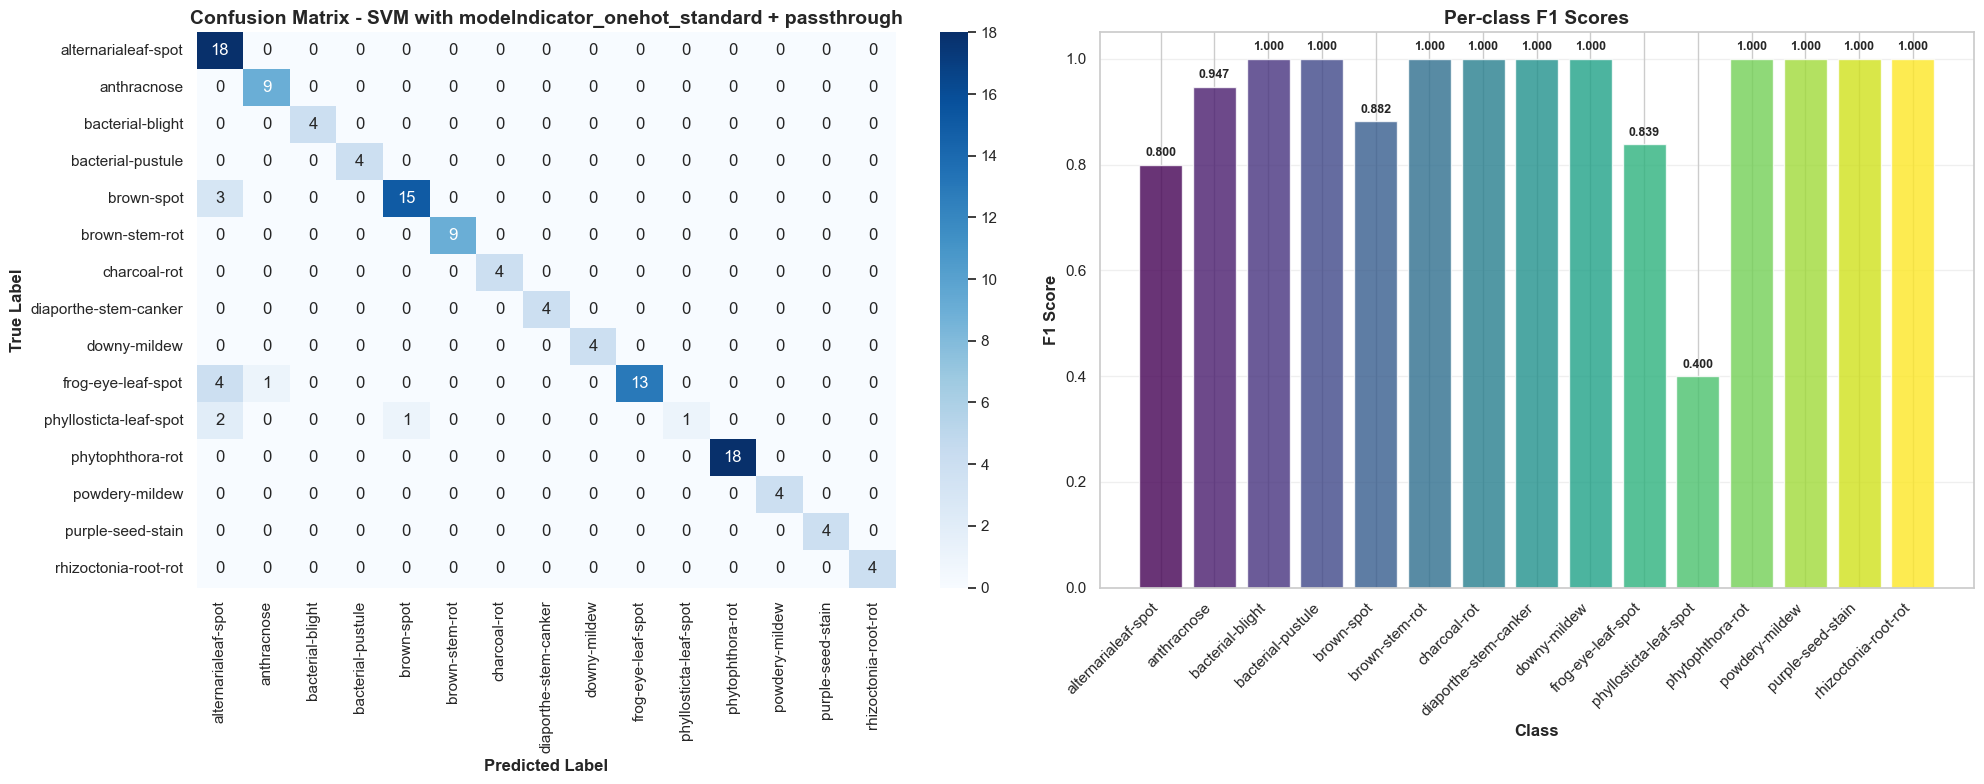

In [24]:
def plot_per_class_analysis(best_model, X_test, y_test, model_name="Best Model"):
    """
    Create per-class performance analysis plots (Confusion Matrix + F1 Scores)
    """
    y_pred = best_model.predict(X_test)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    #confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1,
                xticklabels=best_model.classes_, yticklabels=best_model.classes_)
    ax1.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    ax1.set_ylabel('True Label', fontsize=12, fontweight='bold')
    ax1.set_title(f'Confusion Matrix - {model_name}', fontsize=14, fontweight='bold')
    
    #per-class F1 Scores
    class_report = classification_report(y_test, y_pred, output_dict=True)
    classes = [cls for cls in best_model.classes_ if cls in class_report and cls not in ['accuracy', 'macro avg', 'weighted avg']]
    f1_scores = [class_report[cls]['f1-score'] for cls in classes]
    
    colors = plt.cm.viridis(np.linspace(0, 1, len(classes)))
    bars = ax2.bar(range(len(classes)), f1_scores, color=colors, alpha=0.8)
    ax2.set_xlabel('Class', fontsize=12, fontweight='bold')
    ax2.set_ylabel('F1 Score', fontsize=12, fontweight='bold')
    ax2.set_title('Per-class F1 Scores', fontsize=14, fontweight='bold')
    ax2.set_xticks(range(len(classes)))
    ax2.set_xticklabels(classes, rotation=45, ha='right')
    ax2.grid(True, alpha=0.3, axis='y')
    
    for bar, score in zip(bars, f1_scores):
        ax2.text(bar.get_x() + bar.get_width()/2., score + 0.01, f'{score:.3f}', 
                ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    plt.tight_layout()
    plt.show()

best_overall_row = comprehensive_results_df.iloc[0]
best_model_name = f"{best_overall_row['Classifier']} with {best_overall_row['Preprocessing']} + {best_overall_row['Feature_Selection']}"

preprocessor = ColumnTransformer([
    ('cat', Pipeline([
        ('imputer', imputers[best_overall_row['preprocessing_params']['imputer']]),
        ('encoder', encoders[best_overall_row['preprocessing_params']['encoder']]),
        ('scaler', scalers[best_overall_row['preprocessing_params']['scaler']])
    ]), categorical_features)
])

best_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('feature_selector', feature_selectors[best_overall_row['feature_selector']]),
    ('clf', models[best_overall_row['Classifier']][0])
])

best_pipeline.fit(X_train, y_train)
plot_per_class_analysis(best_pipeline, X_test, y_test, best_model_name)

Finally, looking at the confusion matrix and per class f1 scores for our optimal model, we can see that it struggles most with falsely identifying something as `alternarialeaf-spot` when it is not, happening a total of 9 times. This makes sense, since this class is one of the most represented, being a total of ~14% of all classes. In the f1 scores we can see that the model has a poor score for `phyllosticta-leaf-spot`, which again can be explained by the class imbalance, since this disease is one of the least presented in the data. This means the model was not sufficiently trained to recognize this disease and opted for classifiyng it as a more common disease such as `alternarialeaf-spot` for example.

## Improvements

- using nested cross-validation to better isolate the effect of each pipeline
- comparing with a true baseline model, such as `DummyClassifier`
- whole comparison could be made more efficient by constructing a single pipeline and param_grid instead of multiple for loops